In [2]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
conn = pyodbc.connect(
    r"DRIVER={SQL Server};"
    r"SERVER=DILLIBABU\SQLEXPRESS;"
    r"DATABASE=CFB;"
    r"Trusted_Connection=yes;"
)

print("Connected Successfully!")

Connected Successfully!


In [3]:
 # Load riser table into DataFrame
df = pd.read_sql("SELECT * FROM riser", conn)

C:\Users\dilli\AppData\Local\Temp\ipykernel_6352\1897323906.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM riser", conn)


In [4]:
# Display first 5 rows
print(df.head())

   Ug   Gs     z    r/R  Solid_holdup  Particle_velocity  Solid_flux
0   5  100  0.57  0.000         0.007               6.12       77.86
1   5  100  5.84  0.950         0.027              -0.04       -2.05
2   5  100  5.84  0.837         0.032               2.47      138.94
3   5  100  5.84  0.548         0.010               7.17      128.14
4   5  100  7.78  0.000         0.010               7.81      139.78


In [5]:
# Display dataset structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ug                 1200 non-null   int64  
 1   Gs                 1200 non-null   int64  
 2   z                  1200 non-null   float64
 3   r/R                1200 non-null   float64
 4   Solid_holdup       1200 non-null   float64
 5   Particle_velocity  1200 non-null   float64
 6   Solid_flux         1200 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 65.8 KB
None


In [6]:
# Count missing values
print(df.isnull().sum())

Ug                   0
Gs                   0
z                    0
r/R                  0
Solid_holdup         0
Particle_velocity    0
Solid_flux           0
dtype: int64


In [7]:
# Generate descriptive statistics
print(df.describe())

               Ug           Gs            z          r/R  Solid_holdup  \
count  1200.00000  1200.000000  1200.000000  1200.000000   1200.000000   
mean      7.50000   420.000000     4.825000     0.559667      0.106863   
std       1.53361   246.273308     3.261737     0.322552      0.141197   
min       5.00000   100.000000     0.570000     0.000000      0.005000   
25%       7.00000   200.000000     1.940000     0.316000      0.017000   
50%       7.00000   400.000000     4.275000     0.627500      0.040000   
75%       9.00000   600.000000     7.780000     0.837000      0.124250   
max       9.00000  1000.000000    10.090000     0.950000      0.560000   

       Particle_velocity   Solid_flux  
count        1200.000000  1200.000000  
mean            6.876342   429.659925  
std             6.110575   417.041339  
min            -1.180000  -170.650000  
25%             1.110000   157.407500  
50%             5.950000   321.090000  
75%            10.922500   554.617500  
max          

In [18]:
print(df['Solid_holdup'].describe())

count    1200.000000
mean        0.106863
std         0.141197
min         0.005000
25%         0.017000
50%         0.040000
75%         0.124250
max         0.560000
Name: Solid_holdup, dtype: float64


In [8]:
# Display rows and columns count
print(df.shape)

(1200, 7)


In [9]:
# Count duplicate records
print(df.duplicated().sum())

0


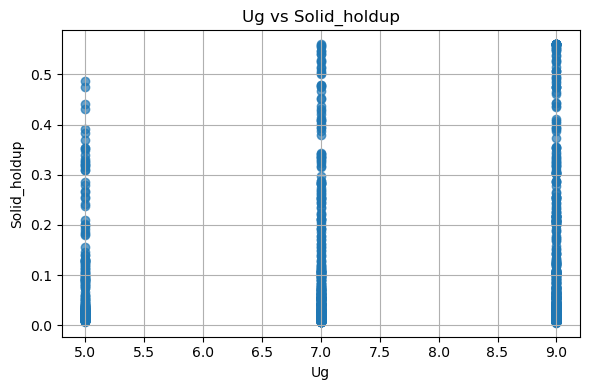

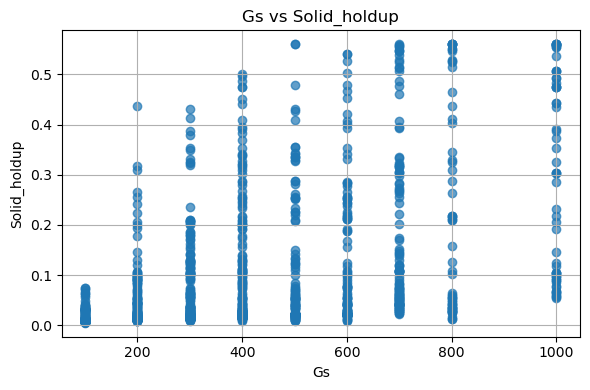

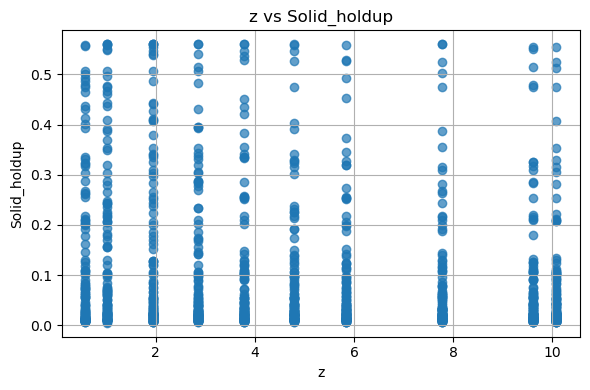

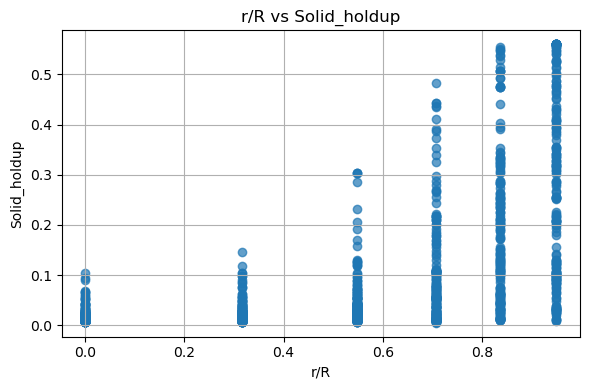

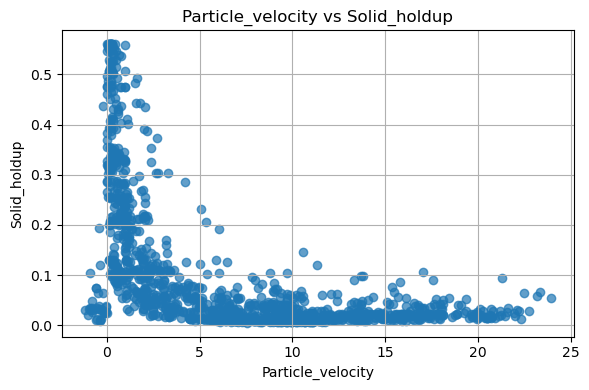

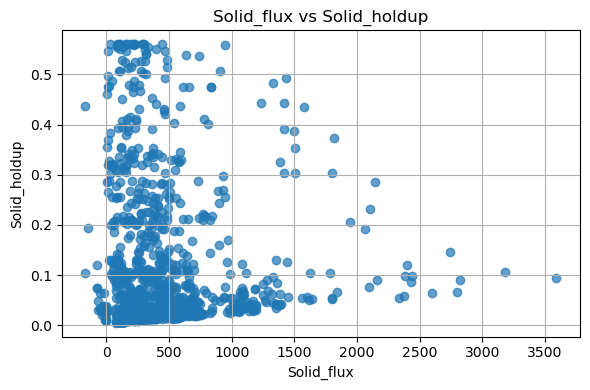

In [20]:
# List of input features
features = ['Ug', 'Gs', 'z', 'r/R', 'Particle_velocity', 'Solid_flux']

# Create scatter plots
for feature in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], df['Solid_holdup'], alpha=0.7)
    plt.xlabel(feature)
    plt.ylabel('Solid_holdup')
    plt.title(f'{feature} vs Solid_holdup')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

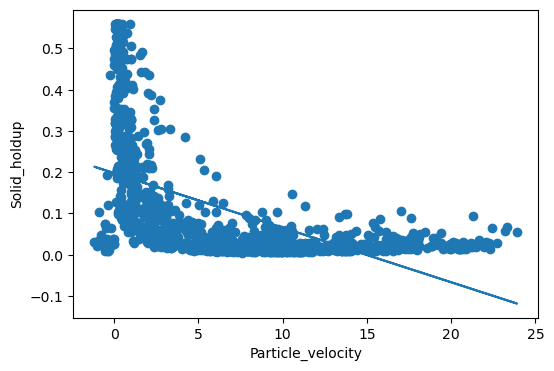

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(df['Particle_velocity'], df['Solid_holdup'])

z = np.polyfit(df['Particle_velocity'],
               df['Solid_holdup'],1)

p = np.poly1d(z)

plt.plot(df['Particle_velocity'],
         p(df['Particle_velocity']))

plt.xlabel('Particle_velocity')
plt.ylabel('Solid_holdup')
plt.show()

In [10]:
# Calculate correlation matrix
print(df.corr(numeric_only=True))

                             Ug            Gs             z           r/R  \
Ug                 1.000000e+00  3.974852e-01  4.338951e-16 -3.893499e-17   
Gs                 3.974852e-01  1.000000e+00  7.186200e-16 -1.969510e-17   
z                  4.338951e-16  7.186200e-16  1.000000e+00  1.830653e-17   
r/R               -3.893499e-17 -1.969510e-17  1.830653e-17  1.000000e+00   
Solid_holdup       1.044034e-01  4.950566e-01 -1.531786e-01  5.550388e-01   
Particle_velocity  1.659483e-01  9.638300e-02  1.902008e-01 -8.663606e-01   
Solid_flux         2.708270e-01  7.049024e-01  9.672161e-02 -3.427794e-01   

                   Solid_holdup  Particle_velocity  Solid_flux  
Ug                     0.104403           0.165948    0.270827  
Gs                     0.495057           0.096383    0.704902  
z                     -0.153179           0.190201    0.096722  
r/R                    0.555039          -0.866361   -0.342779  
Solid_holdup           1.000000          -0.571945   -0.00

In [21]:
corr = df.corr(numeric_only=True)

print(corr['Solid_holdup'].sort_values(ascending=False))

Solid_holdup         1.000000
r/R                  0.555039
Gs                   0.495057
Ug                   0.104403
Solid_flux          -0.003490
z                   -0.153179
Particle_velocity   -0.571945
Name: Solid_holdup, dtype: float64


In [22]:
corr_target = corr['Solid_holdup'].abs().sort_values(ascending=False)

print(corr_target)

Solid_holdup         1.000000
Particle_velocity    0.571945
r/R                  0.555039
Gs                   0.495057
z                    0.153179
Ug                   0.104403
Solid_flux           0.003490
Name: Solid_holdup, dtype: float64


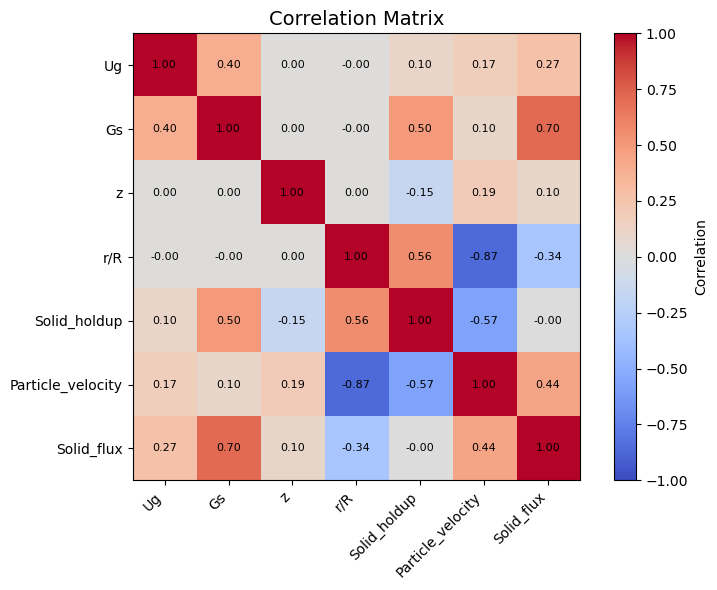

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

# Heatmap
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Color bar
plt.colorbar(im, label='Correlation')

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right', fontsize=10)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=10)

# Add correlation values inside cells
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i,
                 f"{corr.iloc[i, j]:.2f}",
                 ha='center',
                 va='center',
                 color='black',
                 fontsize=8)

plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

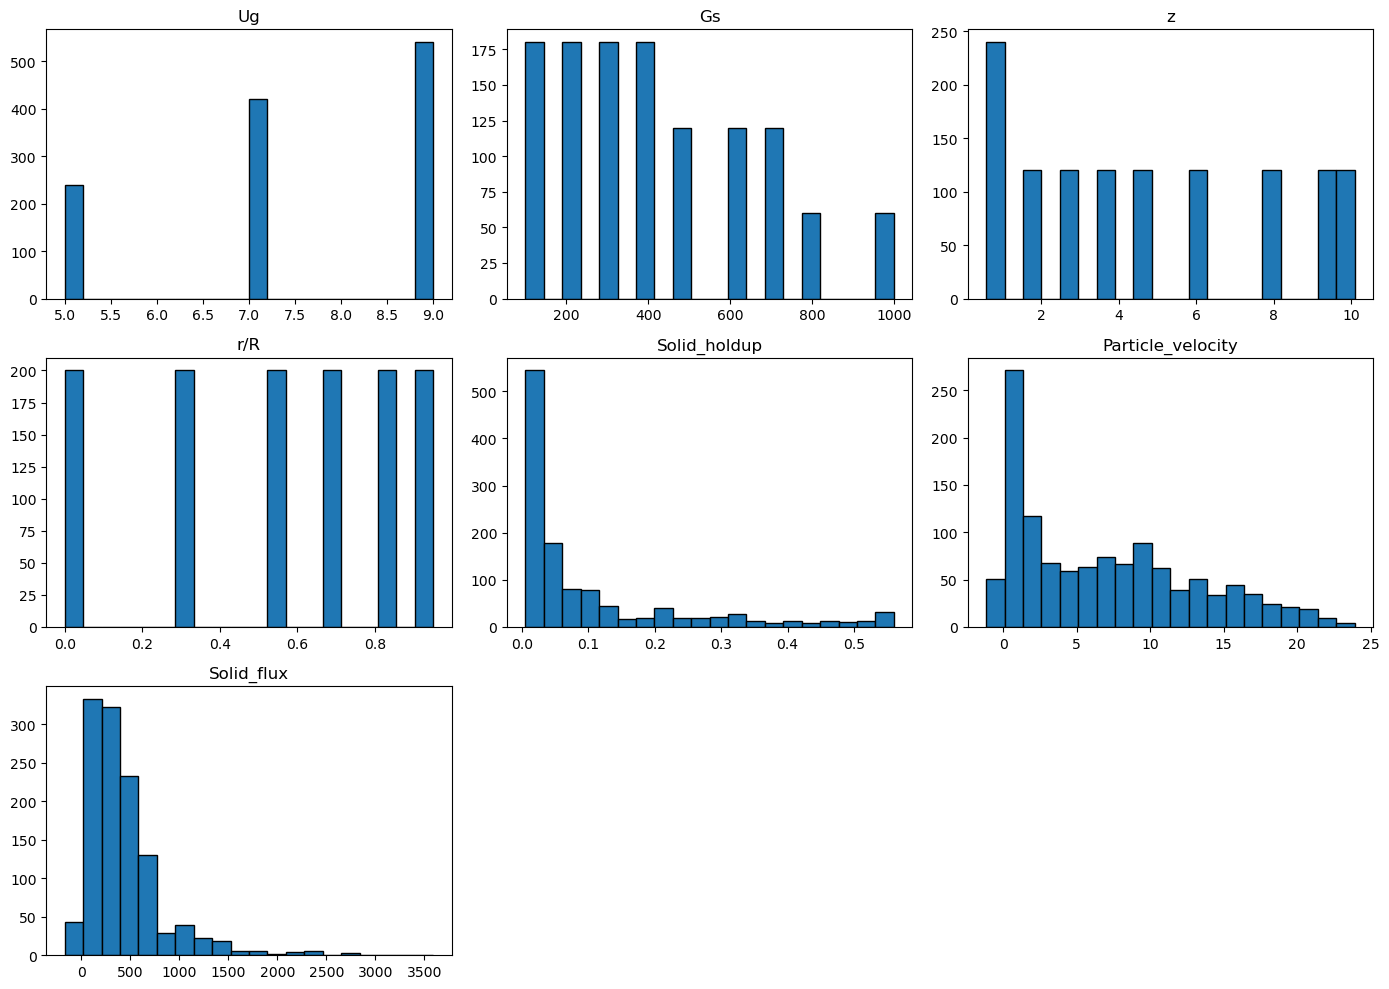

In [11]:
import matplotlib.pyplot as plt

# Histogram for all numerical columns
df.hist(
    bins=20,              # Number of bins
    figsize=(14,10),      # Larger figure
    edgecolor='black',    # Black borders
    grid=False            # Remove grid if not needed
)

plt.tight_layout()
plt.show()

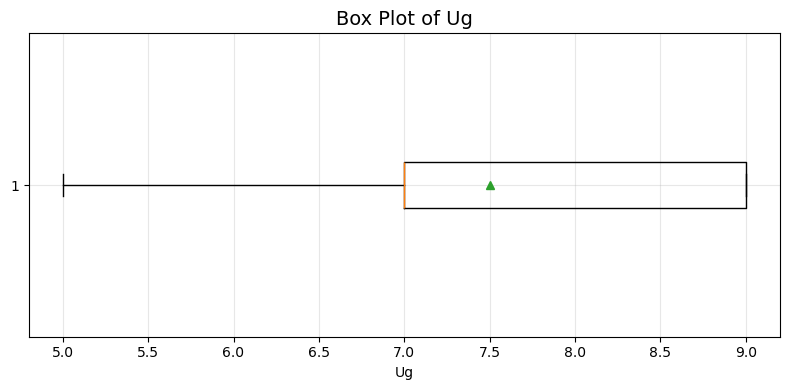

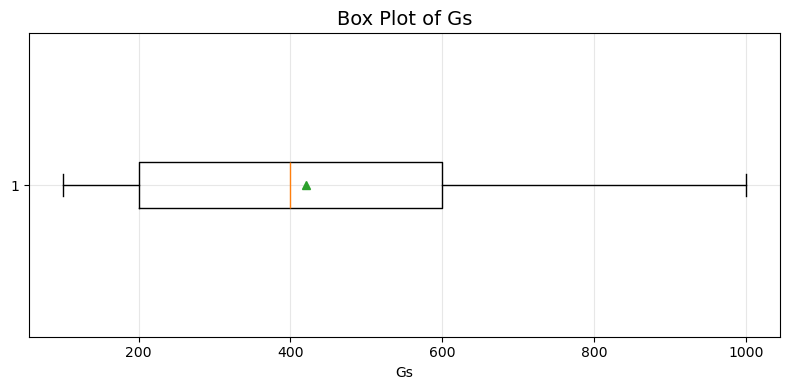

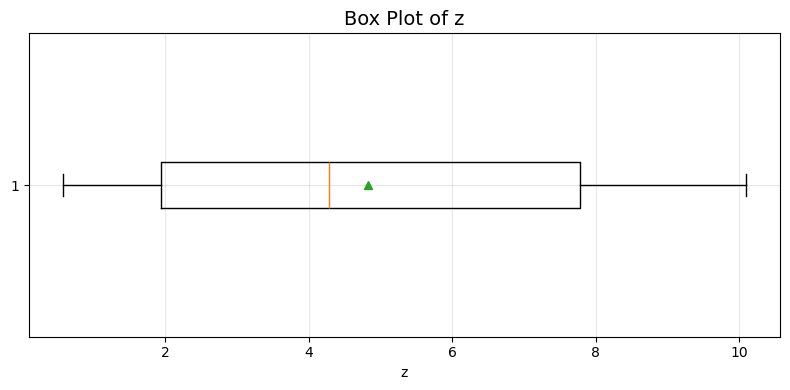

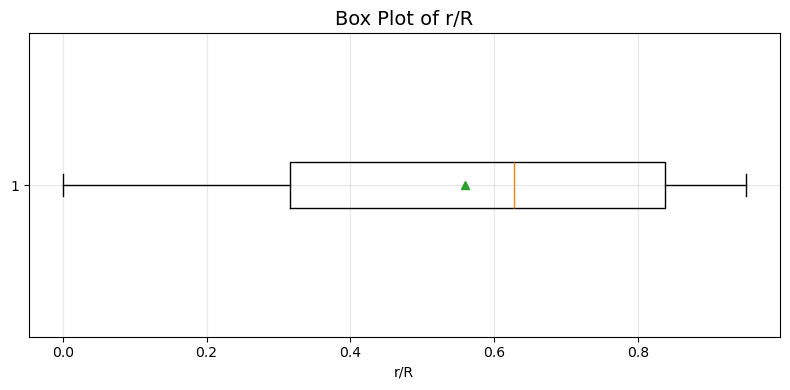

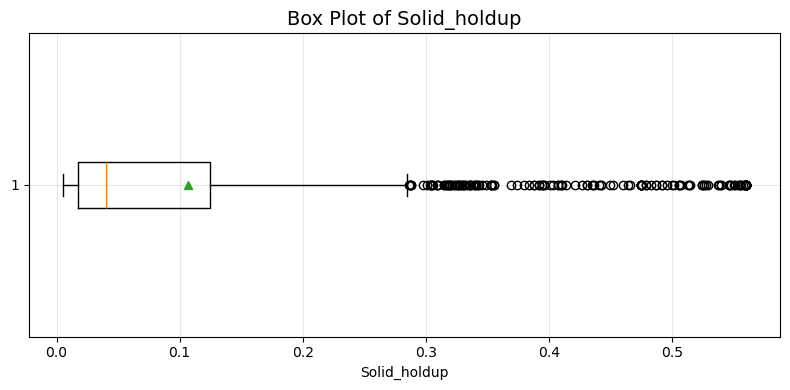

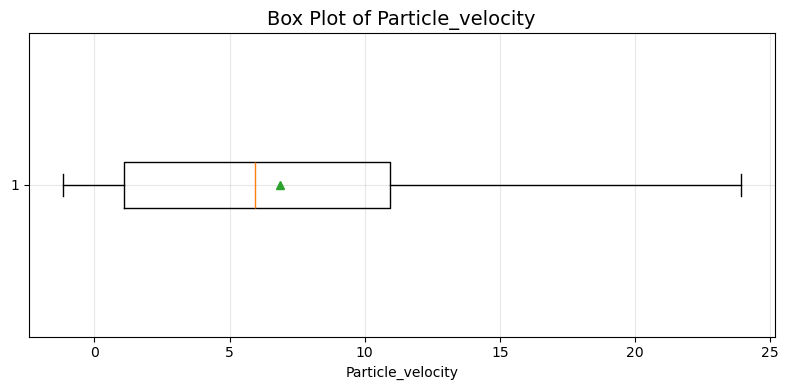

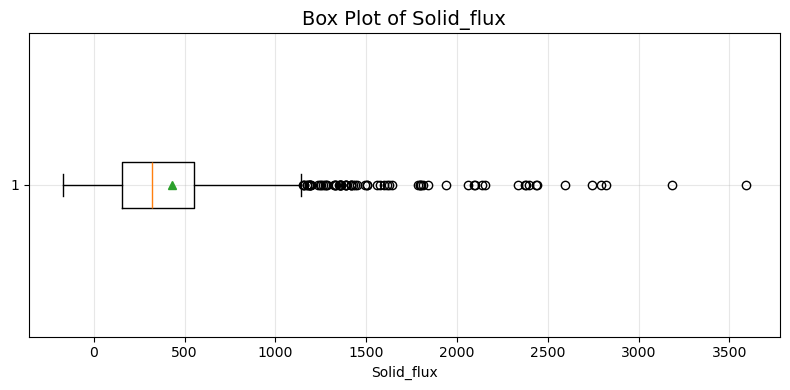

In [12]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8,4))

    plt.boxplot(
        df[col].dropna(),
        vert=False,
        showmeans=True
    )

    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.xlabel(col)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

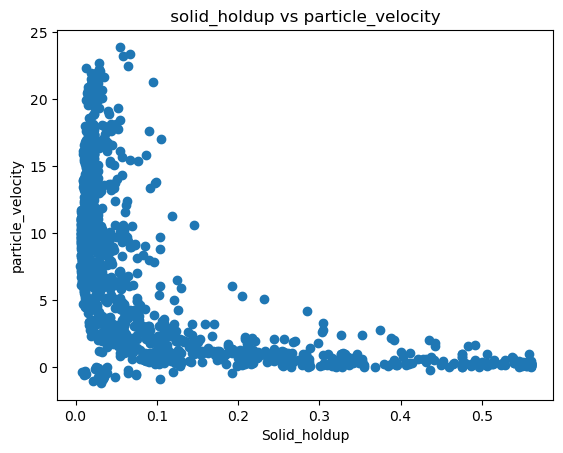

In [13]:
# Plot solid_holdup versus particle_velocity
plt.scatter(df['Solid_holdup'], df['Particle_velocity'])
plt.xlabel('Solid_holdup')
plt.ylabel('particle_velocity')
plt.title(' solid_holdup vs particle_velocity ')
plt.show()

In [14]:
# Calculate mean of numeric columns
print(df.mean(numeric_only=True))

Ug                     7.500000
Gs                   420.000000
z                      4.825000
r/R                    0.559667
Solid_holdup           0.106863
Particle_velocity      6.876342
Solid_flux           429.659925
dtype: float64


In [15]:
# Display maximum values
print(df.max(numeric_only=True))

# Display minimum values
print(df.min(numeric_only=True))

Ug                      9.00
Gs                   1000.00
z                      10.09
r/R                     0.95
Solid_holdup            0.56
Particle_velocity      23.91
Solid_flux           3590.31
dtype: float64
Ug                     5.000
Gs                   100.000
z                      0.570
r/R                    0.000
Solid_holdup           0.005
Particle_velocity     -1.180
Solid_flux          -170.650
dtype: float64


In [29]:
# Save DataFrame to Excel file
df.to_excel('riser_analysis.xlsx', index=False)

In [30]:
# Close SQL Server connection
conn.close()